# Importacion de liberias

In [ ]:
import pandas as pd
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
import seaborn as sns

from funciones import  correlacion_vs_target

from scipy.stats import normaltest



# Cargue de datos

In [2]:
df_empresas = pd.read_csv('../data/raw/empresas afiliadas.csv')

In [5]:
df_empresas.shape

(10000, 16)

# Exploracion de los datos

In [4]:
df_empresas.head()

,id_empresa,ciudad,sector,antiguedad_empresa,distancia_centro,productividad,numero_trabajadores,salario_promedio,rotacion_personal,crecimiento_nomina,numero_servicios,indice_formalizacion,indice_digitalizacion,indice_competencia,satisfaccion_servicio,aporte_mensual
0,1,Bogotá,Hoteles,9.8,52.25,48.1,2,3.53,24.2,-5.4,1,74.3,62.3,31.7,5.7,6119147.0
1,2,Medellín,Construcción,17.5,58.81,54.2,29,4.09,23.1,2.7,1,60.6,71.5,1.9,6.0,10689409.0
2,3,Otras,Minas,7.3,71.78,88.7,3,4.87,13.6,0.5,1,80.2,64.2,82.0,6.4,10001511.0
3,4,Bogotá,Energía,3.4,50.57,65.7,3,4.77,11.7,5.6,1,69.3,66.8,48.1,6.1,8243634.0
4,5,Medellín,Financiero,22.0,4.93,66.7,5,4.87,6.5,0.9,0,73.7,71.2,47.7,5.8,7935528.0


In [5]:
df_empresas.isna().sum()

id_empresa               0
ciudad                   0
sector                   0
antiguedad_empresa       0
distancia_centro         0
productividad            0
numero_trabajadores      0
salario_promedio         0
rotacion_personal        0
crecimiento_nomina       0
numero_servicios         0
indice_formalizacion     0
indice_digitalizacion    0
indice_competencia       0
satisfaccion_servicio    0
aporte_mensual           0
dtype: int64

In [44]:
df_empresas.duplicated(subset='id_empresa').sum()

0

In [7]:
df_empresas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_empresa             10000 non-null  int64  
 1   ciudad                 10000 non-null  object 
 2   sector                 10000 non-null  object 
 3   antiguedad_empresa     10000 non-null  float64
 4   distancia_centro       10000 non-null  float64
 5   productividad          10000 non-null  float64
 6   numero_trabajadores    10000 non-null  int64  
 7   salario_promedio       10000 non-null  float64
 8   rotacion_personal      10000 non-null  float64
 9   crecimiento_nomina     10000 non-null  float64
 10  numero_servicios       10000 non-null  int64  
 11  indice_formalizacion   10000 non-null  float64
 12  indice_digitalizacion  10000 non-null  float64
 13  indice_competencia     10000 non-null  float64
 14  satisfaccion_servicio  10000 non-null  float64
 15  apo

In [8]:
df_empresas.describe()

,id_empresa,antiguedad_empresa,distancia_centro,productividad,numero_trabajadores,salario_promedio,rotacion_personal,crecimiento_nomina,numero_servicios,indice_formalizacion,indice_digitalizacion,indice_competencia,satisfaccion_servicio,aporte_mensual
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,1.000000e+04
mean,5000.50000,13.107150,39.967751,60.810480,20.956400,4.017409,20.20187,6.000370,1.256100,66.364710,65.37049,50.404120,6.443940,1.052534e+07
std,2886.89568,10.528462,23.079048,10.814899,24.399415,0.833040,7.88789,6.035656,1.153796,8.335186,8.89770,28.875506,0.809252,4.895193e+06
min,1.00000,1.000000,0.000000,17.600000,1.000000,1.500000,0.00000,-15.000000,0.000000,31.300000,30.50000,0.000000,3.600000,3.277921e+06
25%,2500.75000,6.000000,20.050000,53.300000,7.000000,3.430000,14.80000,2.000000,0.000000,60.600000,59.50000,25.600000,5.900000,7.634422e+06
50%,5000.50000,9.900000,39.725000,60.600000,14.000000,3.960000,20.70000,6.000000,1.000000,66.300000,65.60000,50.600000,6.400000,9.331664e+06
75%,7500.25000,16.700000,60.122500,68.300000,25.000000,4.580000,26.00000,10.000000,2.000000,71.900000,71.50000,75.600000,7.000000,1.186941e+07
max,10000.00000,60.000000,80.000000,95.000000,353.000000,7.070000,45.60000,29.100000,10.000000,100.000000,96.90000,100.000000,9.600000,7.654771e+07


In [30]:
df_empresas["aporte_mensual"].quantile([
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

0.01     4890383.87
0.05     5847813.70
0.10     6442201.80
0.25     7634422.25
0.50     9331664.00
0.75    11869411.25
0.90    15675326.80
0.95    19137025.25
0.99    29634613.12
Name: aporte_mensual, dtype: float64

C:\Users\NATHNIEAYA\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


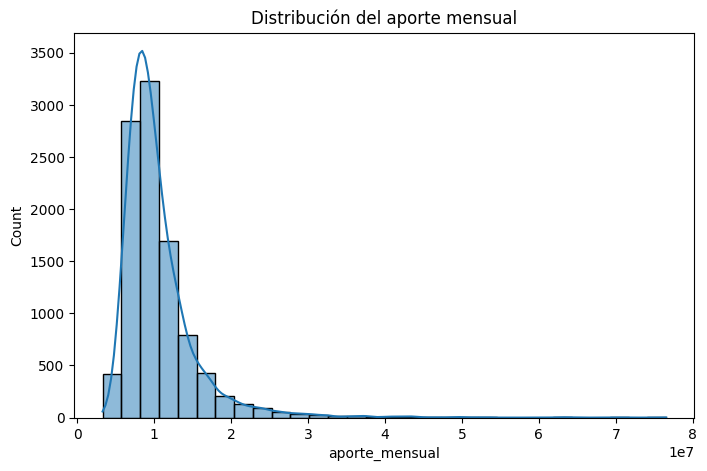

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_empresas["aporte_mensual"],
    bins=30,
    kde=True
)

plt.title("Distribución del aporte mensual")
plt.show()

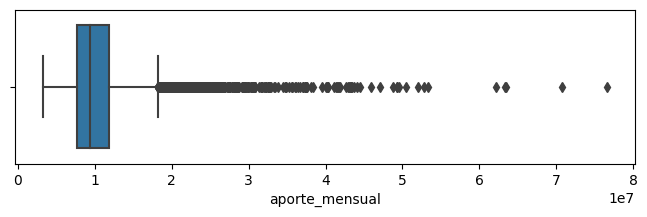

In [32]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df_empresas["aporte_mensual"]
)

plt.show()

Text(0.5, 1.0, 'Log')

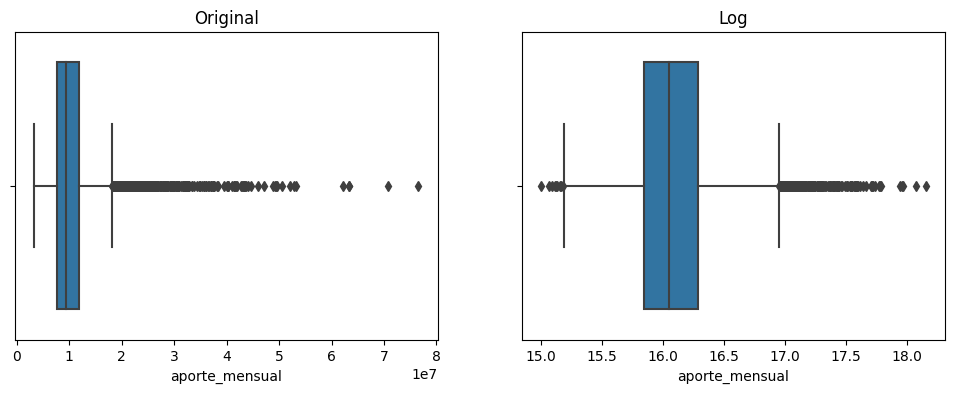

In [40]:
df_empresas["aporte_log"] = np.log(df_empresas["aporte_mensual"])

fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.boxplot(x=df_empresas["aporte_mensual"], ax=ax[0])
ax[0].set_title("Original")

sns.boxplot(x=np.log(df_empresas["aporte_mensual"]), ax=ax[1])
ax[1].set_title("Log")

In [ ]:
stat, p = normaltest(df_empresas["aporte_mensual"])
print(p)

0.0


In [36]:
Q1 = df_empresas["aporte_mensual"].quantile(0.25)
Q3 = df_empresas["aporte_mensual"].quantile(0.75)

IQR = Q3 - Q1
inferior = Q1 - 1.5 * IQR
superior = Q3 + 1.5 * IQR

outliers = df_empresas[
    (df_empresas["aporte_mensual"] < inferior) |
    (df_empresas["aporte_mensual"] > superior)
]

print(outliers.shape)

(584, 16)


In [41]:
columnas = df_empresas.select_dtypes(include="number").columns

for col in columnas:

    Q1 = df_empresas[col].quantile(0.25)
    Q3 = df_empresas[col].quantile(0.75)

    IQR = Q3 - Q1

    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    cantidad = ((df_empresas[col] < inferior) |
                (df_empresas[col] > superior)).sum()

    porcentaje = cantidad / len(df_empresas) * 100

    print(f"{col:25} {cantidad:6} ({porcentaje:.2f}%)")

id_empresa                     0 (0.00%)
antiguedad_empresa           568 (5.68%)
distancia_centro               0 (0.00%)
productividad                 53 (0.53%)
numero_trabajadores          776 (7.76%)
salario_promedio              45 (0.45%)
rotacion_personal              2 (0.02%)
crecimiento_nomina            97 (0.97%)
numero_servicios              30 (0.30%)
indice_formalizacion          79 (0.79%)
indice_digitalizacion         66 (0.66%)
indice_competencia             0 (0.00%)
satisfaccion_servicio         61 (0.61%)
aporte_mensual               584 (5.84%)
aporte_log                   274 (2.74%)


In [38]:
df_empresas.shape

(10000, 16)

### Analisis aportes

<Axes: xlabel='numero_trabajadores', ylabel='aporte_mensual'>

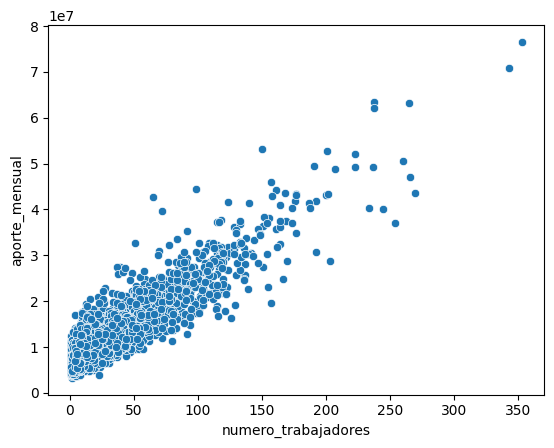

In [ ]:
sns.scatterplot(
    data=df_empresas,
    x="numero_trabajadores",
    y="aporte_mensual"
)

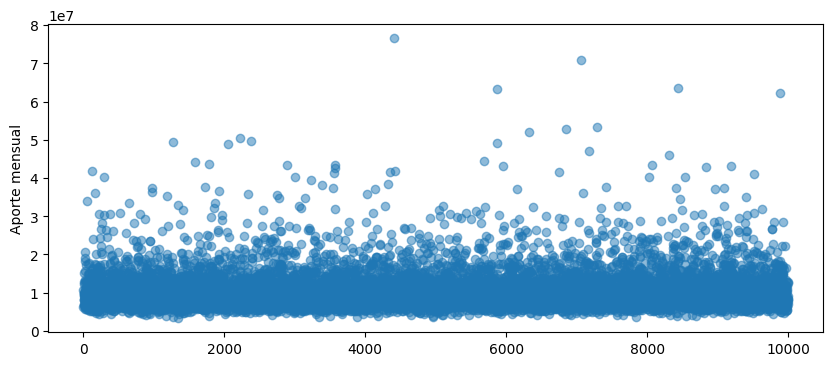

In [39]:
plt.figure(figsize=(10,4))

plt.scatter(
    range(len(df_empresas)),
    df_empresas["aporte_mensual"],
    alpha=0.5
)

plt.ylabel("Aporte mensual")
plt.show()

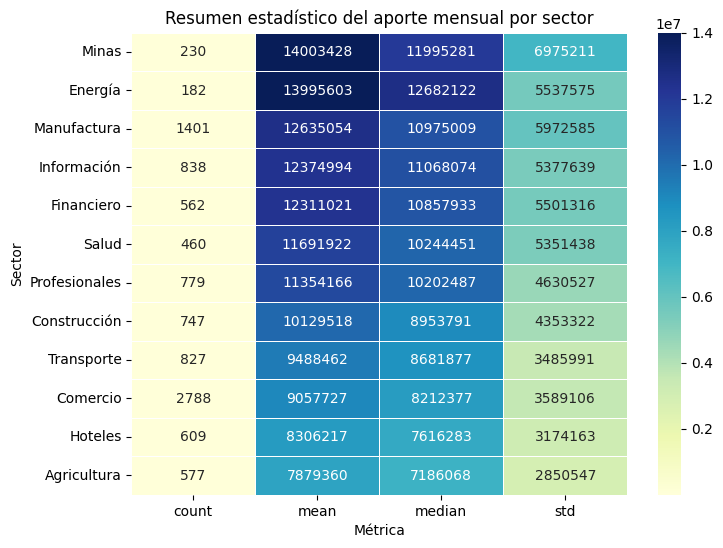

In [ ]:
tabla = (
    df_empresas
    .groupby("sector")["aporte_mensual"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

plt.figure(figsize=(8,6))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=.5
)

plt.title("Resumen estadístico del aporte mensual por sector")
plt.ylabel("Sector")
plt.xlabel("Métrica")
plt.show()

In [23]:
df_empresas['numero_trabajadores'].unique()

array([  2,  29,   3,   5,  11,  21,  20,  35,  31,  14,   7,   9,   6,
        43,  16,  70,  13,  26,  30,  24,  80,  18,  10,  25,   8,  61,
        12, 138,  15,  32,  41,   4,  37,  58,  28,  62,  17,  46,  23,
        19,   1,  22,  55, 192,  54,  44,  73,  27,  36,  33, 128,  78,
        38,  57,  53,  49, 142,  56,  48,  34,  50,  47,  65, 104,  87,
       113, 234, 140,  84,  39, 109,  66,  76, 132,  52,  60,  93,  92,
        45,  42, 130,  59, 115, 137,  71,  99,  40,  74,  97,  83, 112,
        63, 101,  51, 151,  69, 103,  68, 237, 133,  85,  90,  77, 136,
       100,  79, 161,  75, 118,  89, 168, 143,  72, 144,  88,  91, 107,
       207,  81, 260, 147, 191, 110,  96, 124,  94, 102, 114,  67,  82,
       149, 203, 129, 126, 270,  64, 245, 108, 177, 117, 111, 156,  98,
       187, 106, 254, 123,  95, 152,  86, 353, 176, 122, 125, 119, 120,
       131, 167, 223, 265, 154, 139, 200, 164, 201, 343, 266, 155, 150,
       116, 169, 121, 170, 174, 202, 157, 134, 238, 188, 105, 15

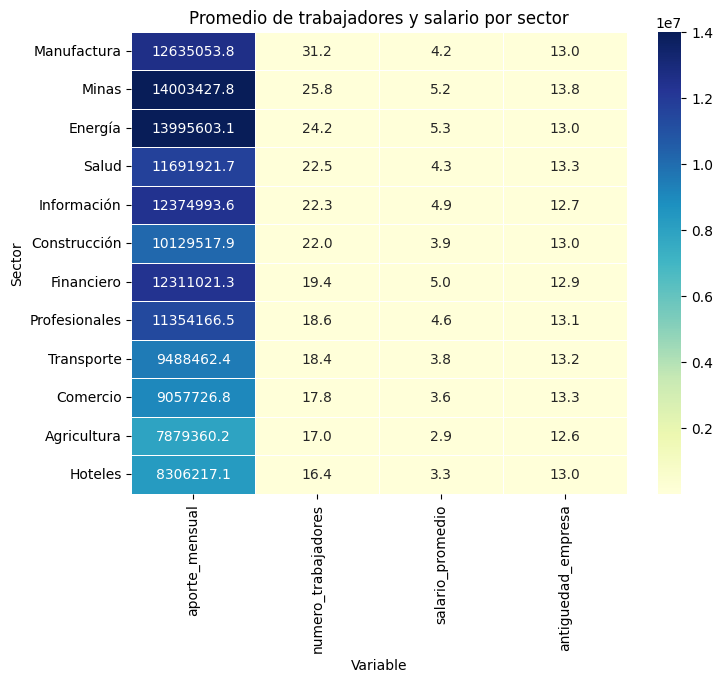

In [ ]:

tabla = (
    df_empresas
    .groupby("sector")[["aporte_mensual","numero_trabajadores", "salario_promedio","antiguedad_empresa"]]
    .mean()
    .sort_values("numero_trabajadores", ascending=False)
)

plt.figure(figsize=(8,6))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Promedio de trabajadores y salario por sector")
plt.ylabel("Sector")
plt.xlabel("Variable")
plt.show()

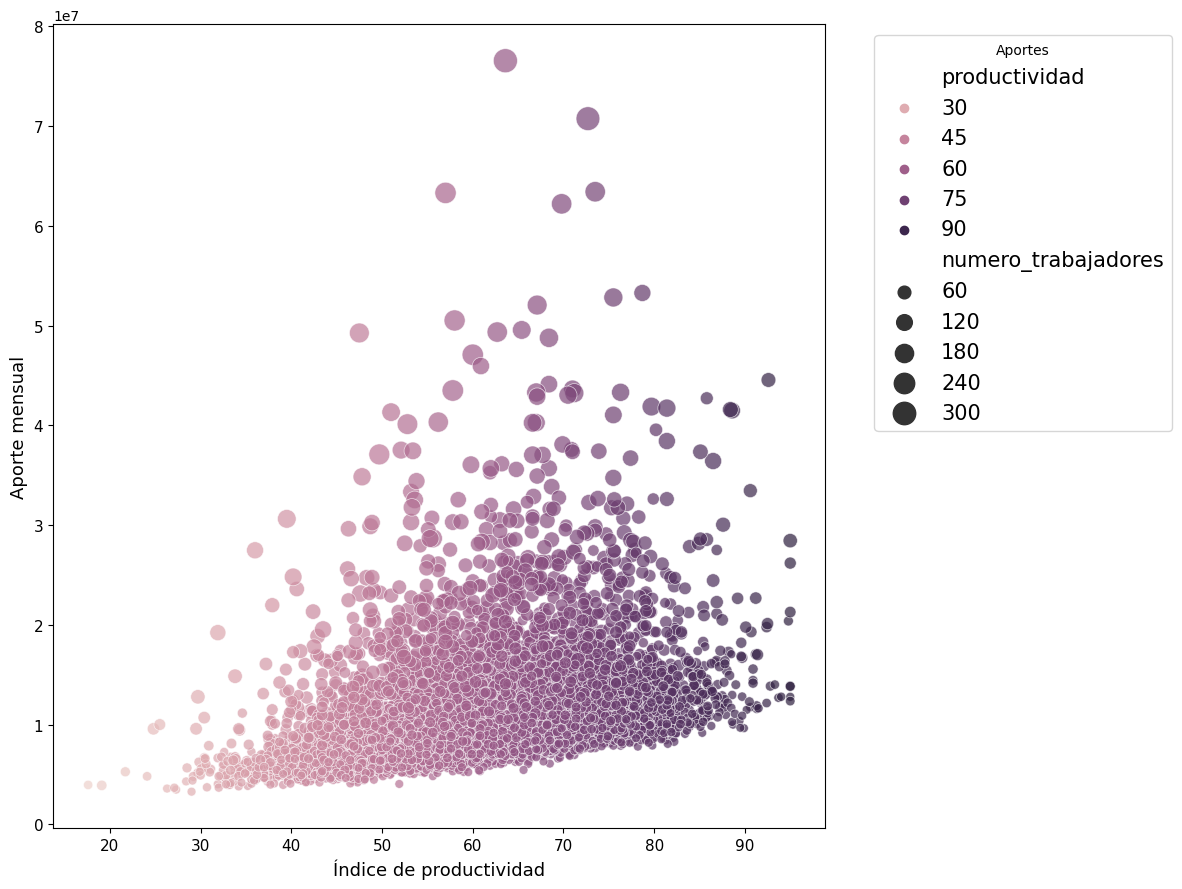

In [28]:
plt.figure(figsize=(12, 9))

sns.scatterplot(
    data=df_empresas,
    x="productividad",
    y="aporte_mensual",
    hue="productividad",
    size="numero_trabajadores",
    sizes=(40, 300),
    alpha=0.7
)

# plt.title("Productividad vs aportes", fontsize=16, weight="bold")
plt.ylabel("Aporte mensual", fontsize=13)
plt.xlabel("Índice de productividad", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(
    title="Aportes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize = 15
)

plt.tight_layout()
plt.show()

### Correlacion de variables

In [42]:
corr = df_empresas.corr(numeric_only=True)
corr["aporte_mensual"].sort_values(ascending=False)

aporte_mensual           1.000000
aporte_log               0.940401
numero_trabajadores      0.892081
productividad            0.380399
salario_promedio         0.368399
indice_formalizacion     0.333760
numero_servicios         0.301006
indice_digitalizacion    0.252027
antiguedad_empresa       0.191012
satisfaccion_servicio    0.132421
crecimiento_nomina       0.039889
id_empresa               0.020913
indice_competencia      -0.004621
distancia_centro        -0.008110
rotacion_personal       -0.277254
Name: aporte_mensual, dtype: float64

In [43]:
resultado_correlacion = correlacion_vs_target(df_empresas, target_col='aporte_mensual')
print(resultado_correlacion)


                 variable  correlacion       metodo        p_value
0              aporte_log     0.940401      Pearson   0.000000e+00
1     numero_trabajadores     0.892081      Pearson   0.000000e+00
2           productividad     0.380399      Pearson   0.000000e+00
3        salario_promedio     0.368399      Pearson  4.752121e-319
4    indice_formalizacion     0.333760      Pearson  9.366599e-259
5        numero_servicios     0.301006      Pearson  1.691113e-208
6       rotacion_personal     0.277254      Pearson  6.430149e-176
7   indice_digitalizacion     0.252027      Pearson  1.062717e-144
8      antiguedad_empresa     0.191012      Pearson   8.447068e-83
9   satisfaccion_servicio     0.132421      Pearson   2.343944e-40
10                 sector     0.129713  Eta Squared  4.083415e-291
11     crecimiento_nomina     0.039889      Pearson   6.608550e-05
12             id_empresa     0.020913      Pearson   3.650091e-02
13                 ciudad     0.016529  Eta Squared   6.727753

In [ ]:
# df_empresas.to_excel('../data/processed/dataset_recaudo.xlsx', index=False)